In [65]:
import sage_data_client
import matplotlib.pyplot as plt
import pandas as pd
from metpy.calc import dewpoint_from_relative_humidity, wet_bulb_temperature
from metpy.units import units
from PIL import Image
import numpy as np
import datetime
import xarray as xr
import glob



from matplotlib.dates import DateFormatter

In [70]:
my_glob = glob.glob('/Users/scollis/data/wxt/CMS_wxt536_ADMIOP2_a1_2024072*')
my_glob.sort()
xr_wxt = xr.open_mfdataset(my_glob)

gaps = np.flatnonzero(np.diff(xr_wxt.time) > np.timedelta64(10, 'm'))
#s1 = xr_wxt['temperature'].append(pd.Series(index=s[gaps].index + np.timedelta64(1, 's'), dtype=float))

xr_wxt['temperature'][gaps]=np.ma.masked
xr_wxt['dewpoint'][gaps]=np.ma.masked
xr_wxt['wetbulb'][gaps]=np.ma.masked
xr_wxt['wind_dir_10s'][gaps]=np.ma.masked
xr_wxt['wind_mean_10s'][gaps]=np.ma.masked
xr_wxt['rainfall'][gaps]=np.ma.masked


In [71]:
my_glob

['/Users/scollis/data/wxt/CMS_wxt536_ADMIOP2_a1_20240726_000000Z.nc',
 '/Users/scollis/data/wxt/CMS_wxt536_ADMIOP2_a1_20240727_000000Z.nc',
 '/Users/scollis/data/wxt/CMS_wxt536_ADMIOP2_a1_20240728_000000Z.nc']

In [72]:
xr_wxt

<xarray.Dataset>
Dimensions:        (time: 13341)
Coordinates:
  * time           (time) datetime64[ns] 2024-07-26T21:28:20 ... 2024-07-28T1...
Data variables:
    temperature    (time) float64 dask.array<chunksize=(898,), meta=np.ndarray>
    humidity       (time) float64 dask.array<chunksize=(898,), meta=np.ndarray>
    pressure       (time) float64 dask.array<chunksize=(898,), meta=np.ndarray>
    rainfall       (time) float64 dask.array<chunksize=(898,), meta=np.ndarray>
    dewpoint       (time) float64 dask.array<chunksize=(898,), meta=np.ndarray>
    wetbulb        (time) float64 dask.array<chunksize=(898,), meta=np.ndarray>
    wind_dir_10s   (time) float64 dask.array<chunksize=(898,), meta=np.ndarray>
    wind_mean_10s  (time) float64 dask.array<chunksize=(898,), meta=np.ndarray>
    wind_max_10s   (time) float64 dask.array<chunksize=(898,), meta=np.ndarray>
Attributes:
    conventions:  CF 1.10
    WSN:          W09E
    site_ID:      ADMIOP2
    CAMS_tag:     CMS-WXT-00X
    datastream:   CMS_wxt536_ADMIOP2_a1
    plugin:       10.31.81.1:5000/local/waggle-wxt536.*
    datalevel:    a1
    latitude:     41.867614285
    longitude:    -87.649490603

(5.0, 35.0)

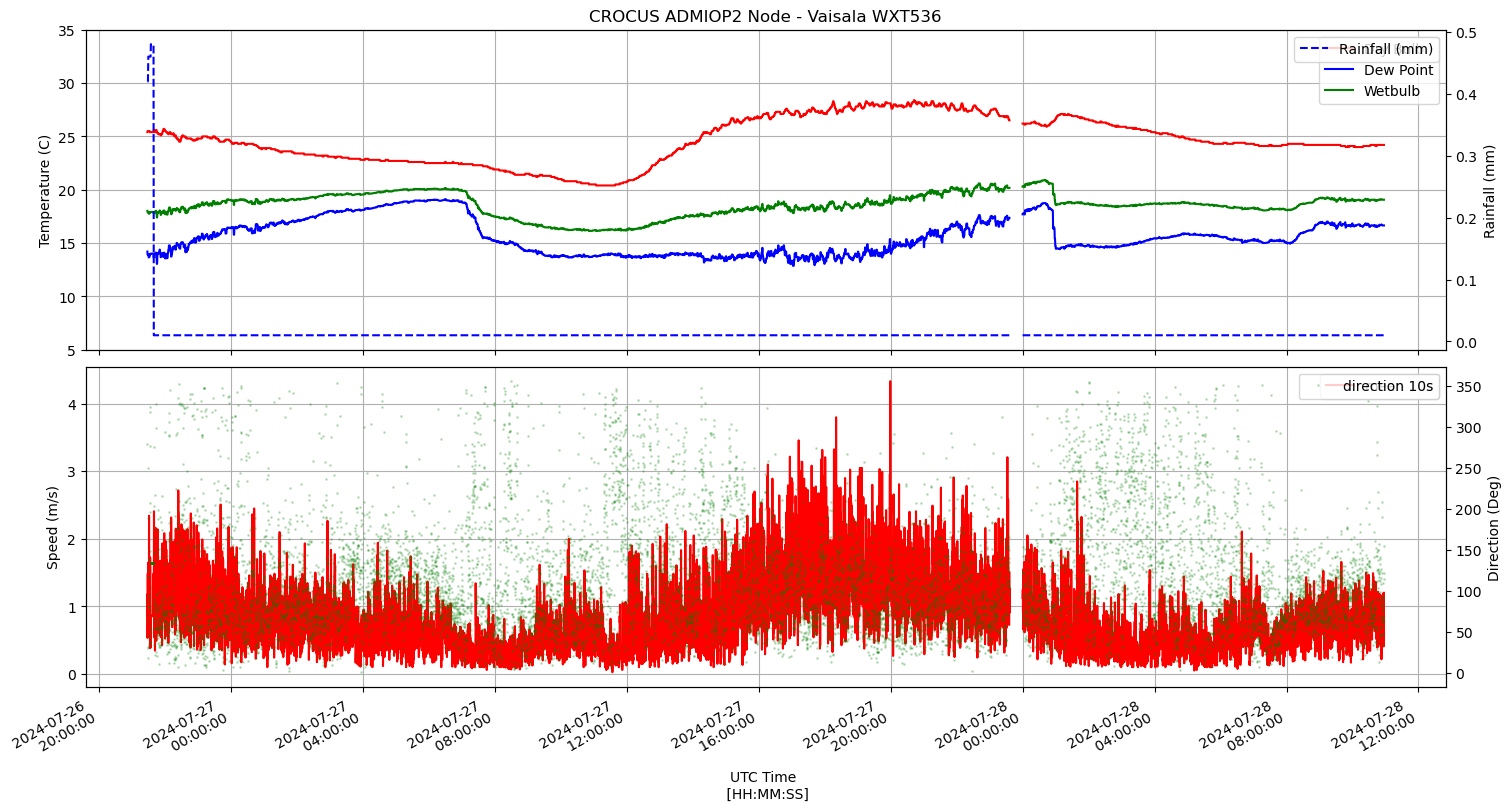

In [73]:
time1 = None #pd.Timestamp("2024-06-26 19:00:01")
time2 = None #pd.Timestamp("2024-06-27 17:59:00")

fig, axs = plt.subplots( ncols=1, nrows=2, figsize=[15,8], constrained_layout=True)
xr_wxt.temperature.plot(ax=axs[0], color='r', label='Dry Bulb')
xr_wxt.dewpoint.plot(color='b', label='Dew Point',ax=axs[0])
xr_wxt.wetbulb.plot(color='g', label='Wetbulb',ax=axs[0])

xr_wxt.wind_mean_10s.plot(ax=axs[1], color='r', label='mean 10s')
ytwin = plt.twinx()

xr_wxt.wind_dir_10s.plot(ax=ytwin, color='g', label='direction 10s', marker='.', linestyle='none', 
                         markersize=2, alpha = 0.2)

axs[0].set_title('CROCUS ' + xr_wxt.site_ID  + ' Node - Vaisala WXT536')
axs[0].set_xlabel('')
axs[0].set_ylabel('Temperature (C)')


axs[1].set_xlabel('UTC Time \n [HH:MM:SS]')
axs[1].set_ylabel('Speed (m/s)')
axs[0].grid()
axs[1].grid()

my_twin = plt.twinx(ax = axs[0])
xr_wxt.rainfall.plot(ax=my_twin, label = 'Rainfall (mm)', color='b', linestyle='dashed')

my_twin.set_ylabel('Rainfall (mm)')
my_twin.legend(loc=1)


axs[0].legend()
axs[0].grid(True)

axs[1].legend()
axs[1].grid(True)

ytwin.set_ylabel('Direction (Deg)')
ytwin.legend(loc=1)

date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")

axs[1].xaxis.set_major_formatter(date_form)
axs[0].set_xticklabels([])

axs[1].set_xlim(time1, time2)
axs[0].set_xlim(time1, time2)

#my_twin.set_ylim(30,85)
axs[0].set_ylim(5,35)






(-3.0, 30.0)

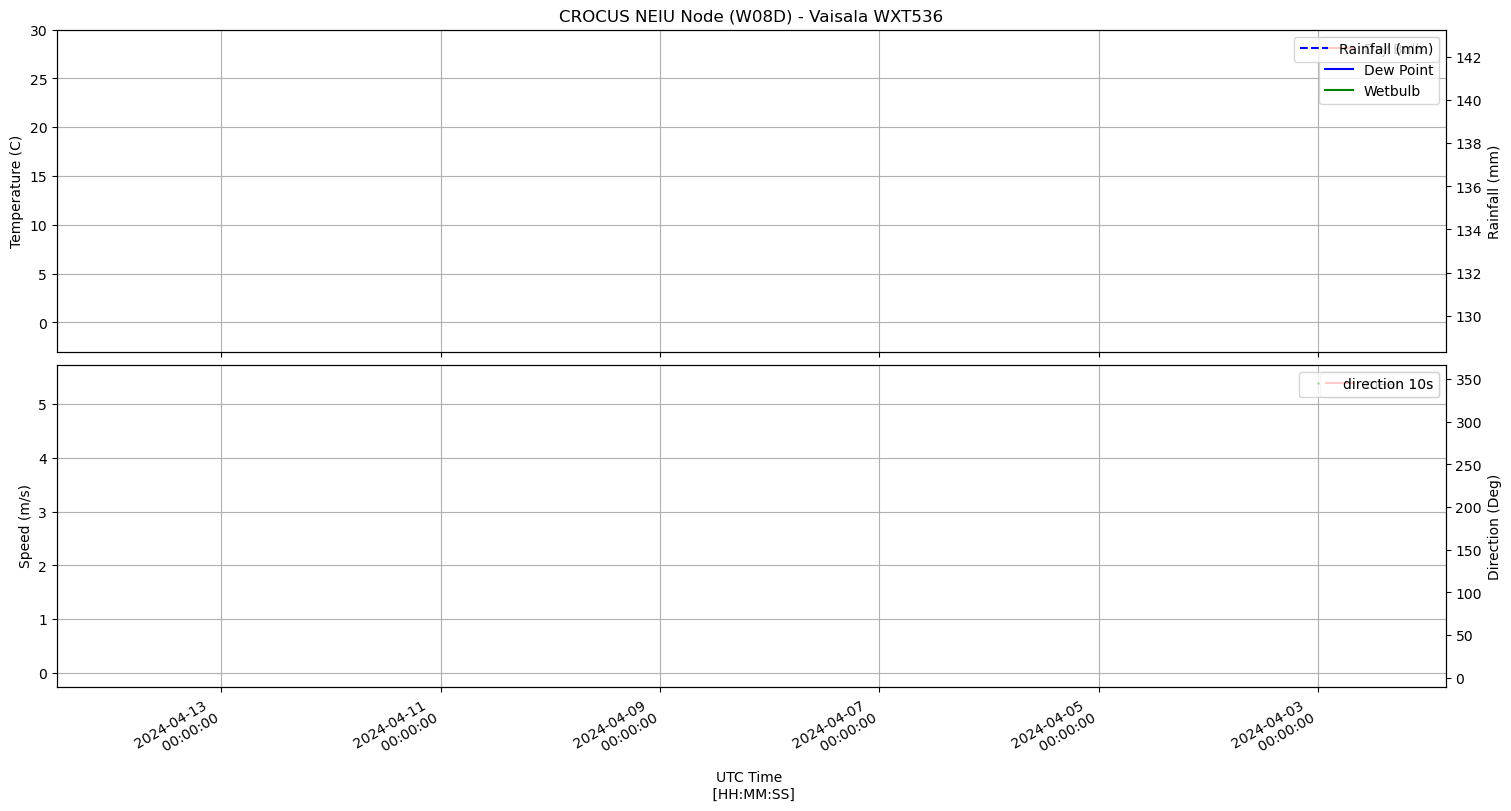

In [6]:
time1 = pd.Timestamp("2024-04-14 12:00:00")
time2 = pd.Timestamp("2024-04-1 20:00:00")


fig, axs = plt.subplots( ncols=1, nrows=2, figsize=[15,8], constrained_layout=True)
xr_wxt.temperature.plot(ax=axs[0], color='r', label='Dry Bulb')
xr_wxt.dewpoint.plot(color='b', label='Dew Point',ax=axs[0])
xr_wxt.wetbulb.plot(color='g', label='Wetbulb',ax=axs[0])

xr_wxt.wind_mean_10s.plot(ax=axs[1], color='r', label='mean 10s')
ytwin = plt.twinx()

xr_wxt.wind_dir_10s.plot(ax=ytwin, color='g', label='direction 10s', marker='.', linestyle='none', 
                         markersize=2, alpha = 0.2)

axs[0].set_title('CROCUS NEIU Node (W08D) - Vaisala WXT536')
axs[0].set_xlabel('')
axs[0].set_ylabel('Temperature (C)')


axs[1].set_xlabel('UTC Time \n [HH:MM:SS]')
axs[1].set_ylabel('Speed (m/s)')
axs[0].grid()
axs[1].grid()

my_twin = plt.twinx(ax = axs[0])
xr_wxt.rainfall.plot(ax=my_twin, label = 'Rainfall (mm)', color='b', linestyle='dashed')

my_twin.set_ylabel('Rainfall (mm)')
my_twin.legend(loc=1)


axs[0].legend()
axs[0].grid(True)

axs[1].legend()
axs[1].grid(True)

ytwin.set_ylabel('Direction (Deg)')
ytwin.legend(loc=1)

date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")

axs[1].xaxis.set_major_formatter(date_form)
axs[0].set_xticklabels([])

axs[1].set_xlim(time1, time2)
axs[0].set_xlim(time1, time2)

#my_twin.set_ylim(30,85)
axs[0].set_ylim(-3,30)







In [71]:
xr_aqt = xr.open_mfdataset('/Users/scollis/data/aqt/CMS_AQT580_UIC_a1_2024071*')

In [60]:
my_glob = glob.glob('/Users/scollis/data/aqt/CMS_AQT580_ADMIOP2_a1_2024072*')
xr_aqt = xr.open_mfdataset(my_glob)

In [61]:
my_glob

['/Users/scollis/data/aqt/CMS_AQT580_ADMIOP2_a1_20240726_000000Z.nc',
 '/Users/scollis/data/aqt/CMS_AQT580_ADMIOP2_a1_20240728_000000Z.nc',
 '/Users/scollis/data/aqt/CMS_AQT580_ADMIOP2_a1_20240727_000000Z.nc']

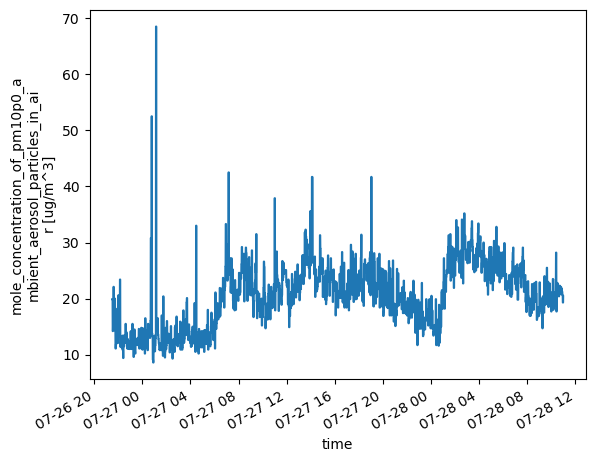

In [62]:
xr_aqt['pm10.0'].plot()

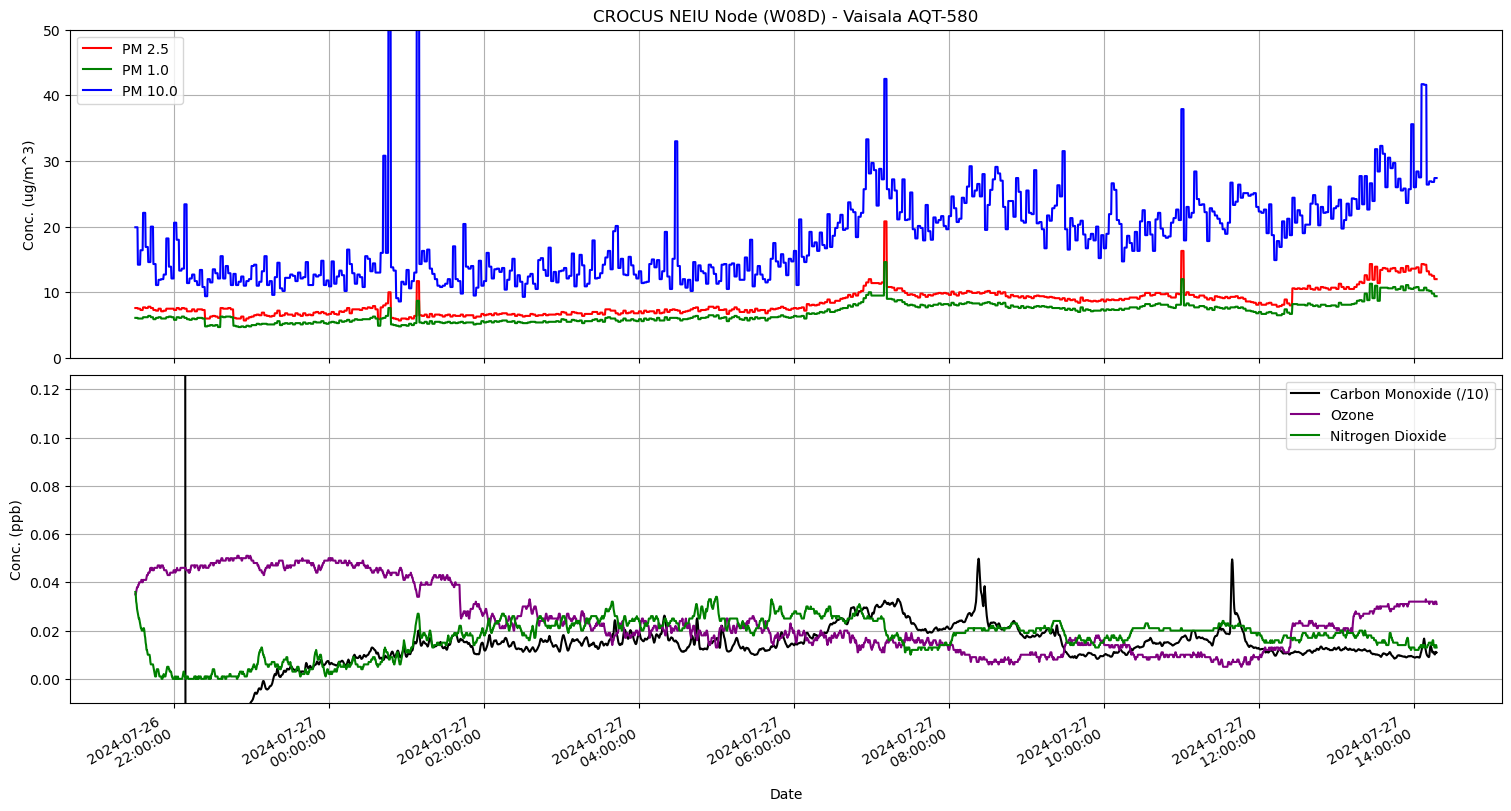

In [48]:
#time1 = pd.Timestamp("2023-08-01 00:00:00")
#time2 = pd.Timestamp("2023-09-10 23:00:00")

#time1 = pd.Timestamp("2024-05-17 09:00:01")
#time2 = pd.Timestamp("2024-05-17 23:59:00")


fig, axs = plt.subplots( ncols=1, nrows=2, figsize=[15,8], constrained_layout=True)
xr_aqt['pm2.5'].plot(ax=axs[0], color='r', label='PM 2.5')
xr_aqt['pm1.0'].plot(ax=axs[0], color='g', label='PM 1.0')
xr_aqt['pm10.0'].plot(ax=axs[0], color='b', label='PM 10.0')

(xr_aqt.co/10.).plot(ax=axs[1], color='k', label='Carbon Monoxide (/10)')
xr_aqt.o3.plot(ax=axs[1], color='purple', label='Ozone')
#xr_aqt.no.plot(ax=axs[1], color='r', label='Nitrogen Monoxide ')
xr_aqt.no2.plot(ax=axs[1], color='g', label='Nitrogen Dioxide')

axs[0].set_ylim([0, 50])

axs[0].set_title('CROCUS NEIU Node (W08D) - Vaisala AQT-580')
axs[0].set_xlabel('')
axs[0].set_ylabel('Conc. (ug/m^3)')

axs[0].legend()

axs[1].set_title('')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Conc. (ppb)')

axs[1].legend()

axs[0].set_xlim(time1, time2)
axs[1].set_xlim(time1, time2)
axs[1].set_ylim([-0.01,0.126])
axs[0].set_xticklabels([])
axs[0].grid()
axs[1].grid()
date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")
axs[1].xaxis.set_major_formatter(date_form)


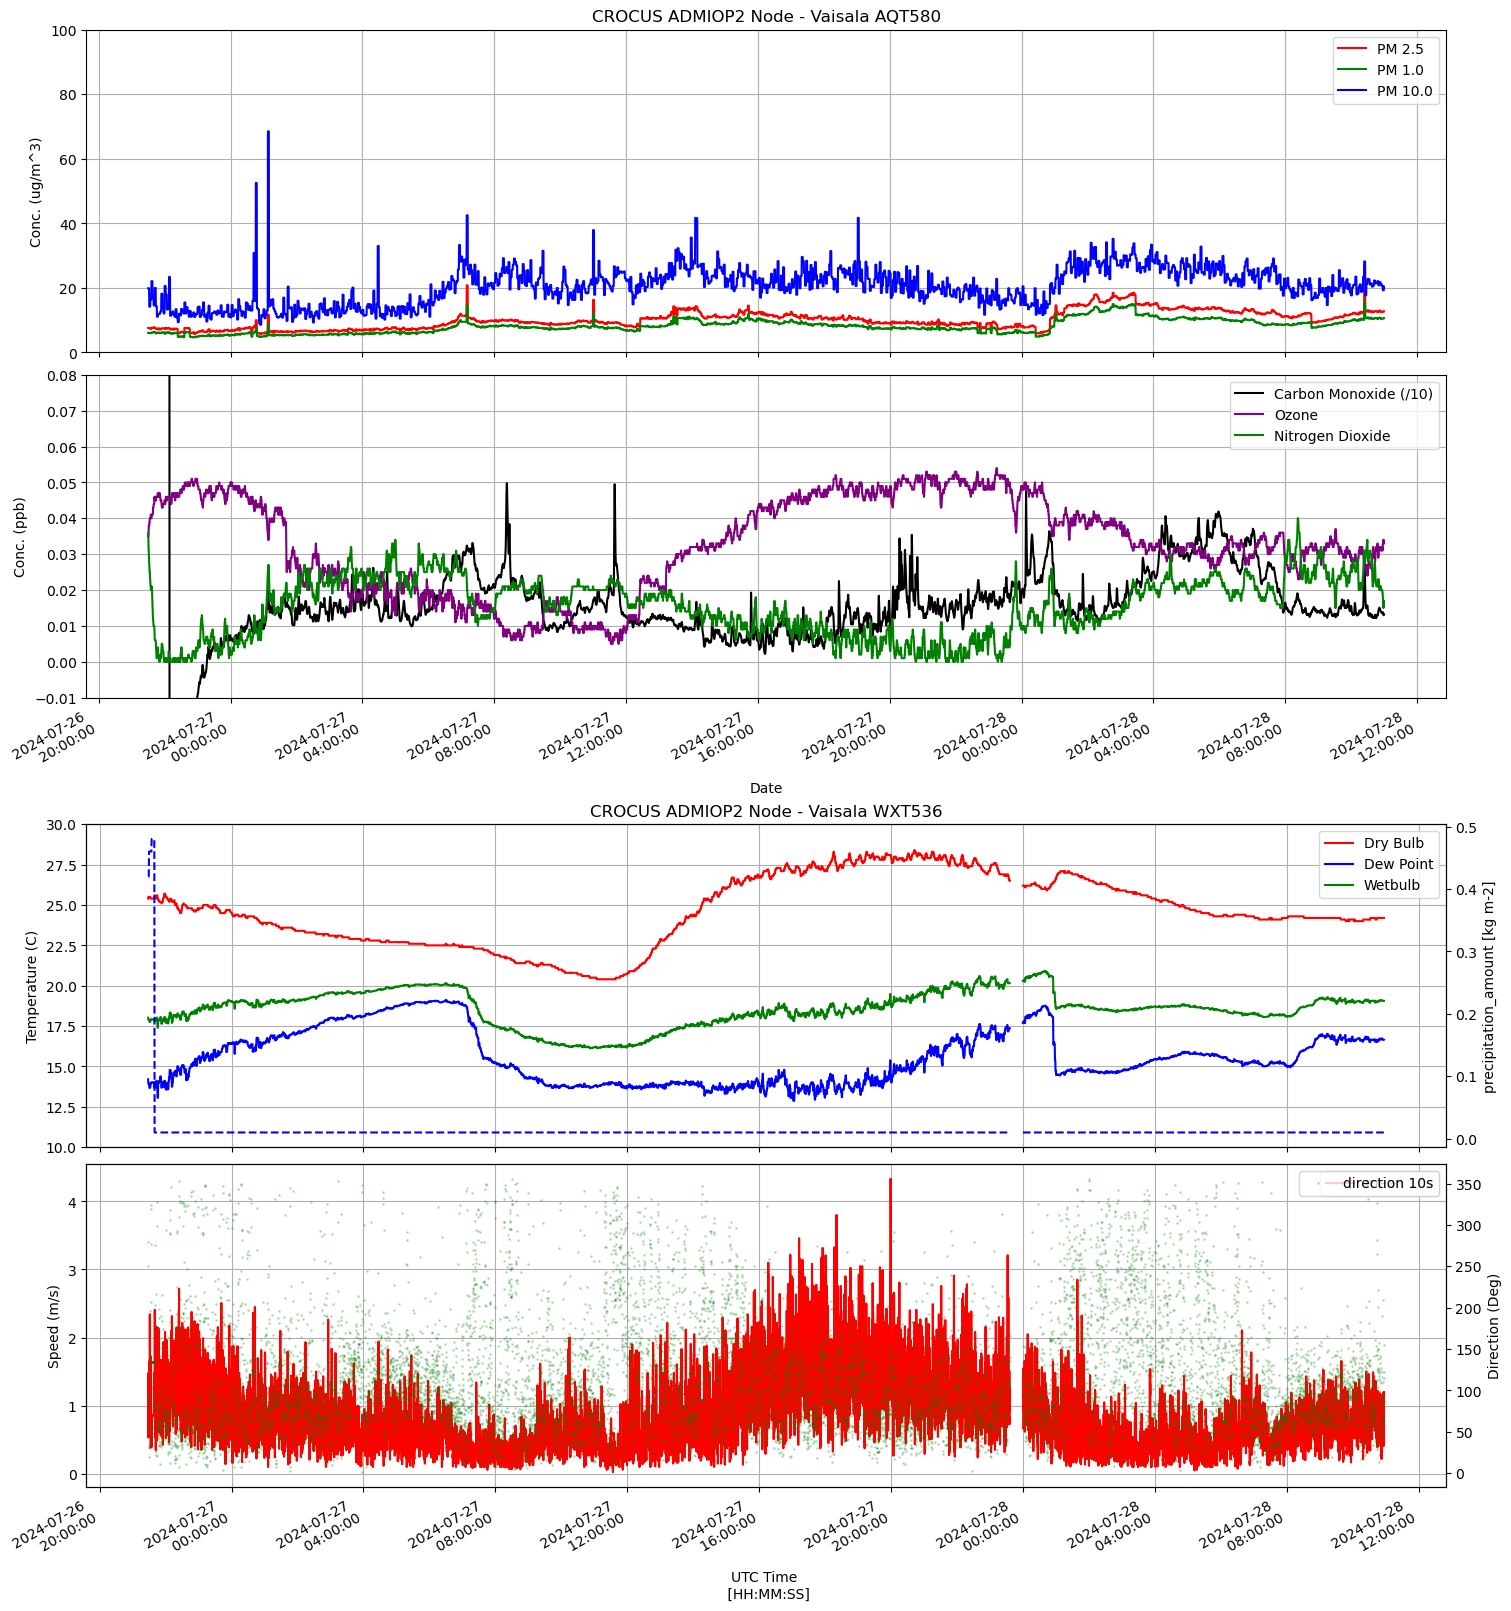

In [74]:
#time1 = pd.Timestamp("2024-07-22 12:00:00")
#time2 = pd.Timestamp("2024-07-25 05:00:00")
#time1 = pd.Timestamp("2024-05-26 09:00:01")
#time2 = pd.Timestamp("2024-05-27 23:59:00")



fig, axs = plt.subplots( ncols=1, nrows=4, figsize=[15,16], constrained_layout=True)
xr_aqt['pm2.5'].plot(ax=axs[0], color='r', label='PM 2.5')
xr_aqt['pm1.0'].plot(ax=axs[0], color='g', label='PM 1.0')
xr_aqt['pm10.0'].plot(ax=axs[0], color='b', label='PM 10.0')

(xr_aqt.co/10.).plot(ax=axs[1], color='k', label='Carbon Monoxide (/10)')
xr_aqt.o3.plot(ax=axs[1], color='purple', label='Ozone')
#xr_aqt.no.plot(ax=axs[1], color='r', label='Nitrogen Monoxide ')
xr_aqt.no2.plot(ax=axs[1], color='g', label='Nitrogen Dioxide')

axs[0].set_ylim([0, 100])

axs[0].set_title('CROCUS ' + xr_wxt.site_ID  + ' Node - Vaisala AQT580' )
axs[0].set_xlabel('')
axs[0].set_ylabel('Conc. (ug/m^3)')

axs[0].legend()

axs[1].set_title('')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Conc. (ppb)')

axs[1].legend()

axs[0].set_xlim(time1, time2)
axs[1].set_xlim(time1, time2)
axs[1].set_ylim([-0.01,0.08])
axs[0].set_xticklabels([])
axs[0].grid()
axs[1].grid()
date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")
axs[1].xaxis.set_major_formatter(date_form)


xr_wxt.temperature.plot(ax=axs[2], color='r', label='Dry Bulb')
xr_wxt.dewpoint.plot(color='b', label='Dew Point',ax=axs[2])
xr_wxt.wetbulb.plot(color='g', label='Wetbulb',ax=axs[2])

xr_wxt.wind_mean_10s.plot(ax=axs[3], color='r', label='mean 10s')
ytwin2 = plt.twinx()

xr_wxt.wind_dir_10s.plot(ax=ytwin2, color='g', label='direction 10s', marker='.', linestyle='none', 
                         markersize=2, alpha = 0.2)

axs[2].set_title('CROCUS ' + xr_wxt.site_ID  + ' Node - Vaisala WXT536')
axs[2].set_xlabel('')
axs[2].set_ylabel('Temperature (C)')


axs[3].set_xlabel('UTC Time \n [HH:MM:SS]')
axs[3].set_ylabel('Speed (m/s)')
axs[2].grid()
axs[3].grid()

my_twin2 = plt.twinx(ax = axs[2])
xr_wxt.rainfall.plot(ax=my_twin2, label = 'Rainfall (mm)', color='b', linestyle='dashed')

my_twin.set_ylabel('Rainfall (mm)')
my_twin.legend(loc=1)


axs[2].legend()
axs[2].grid(True)

axs[3].legend()
axs[3].grid(True)

ytwin2.set_ylabel('Direction (Deg)')
ytwin2.legend(loc=1)

date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")

axs[3].xaxis.set_major_formatter(date_form)
axs[2].set_xticklabels([])

axs[3].set_xlim(time1, time2)
axs[2].set_xlim(time1, time2)

#my_twin.set_ylim(30,85)
axs[2].set_ylim(10,30)

plt.savefig('/Users/scollis/UIC.png')





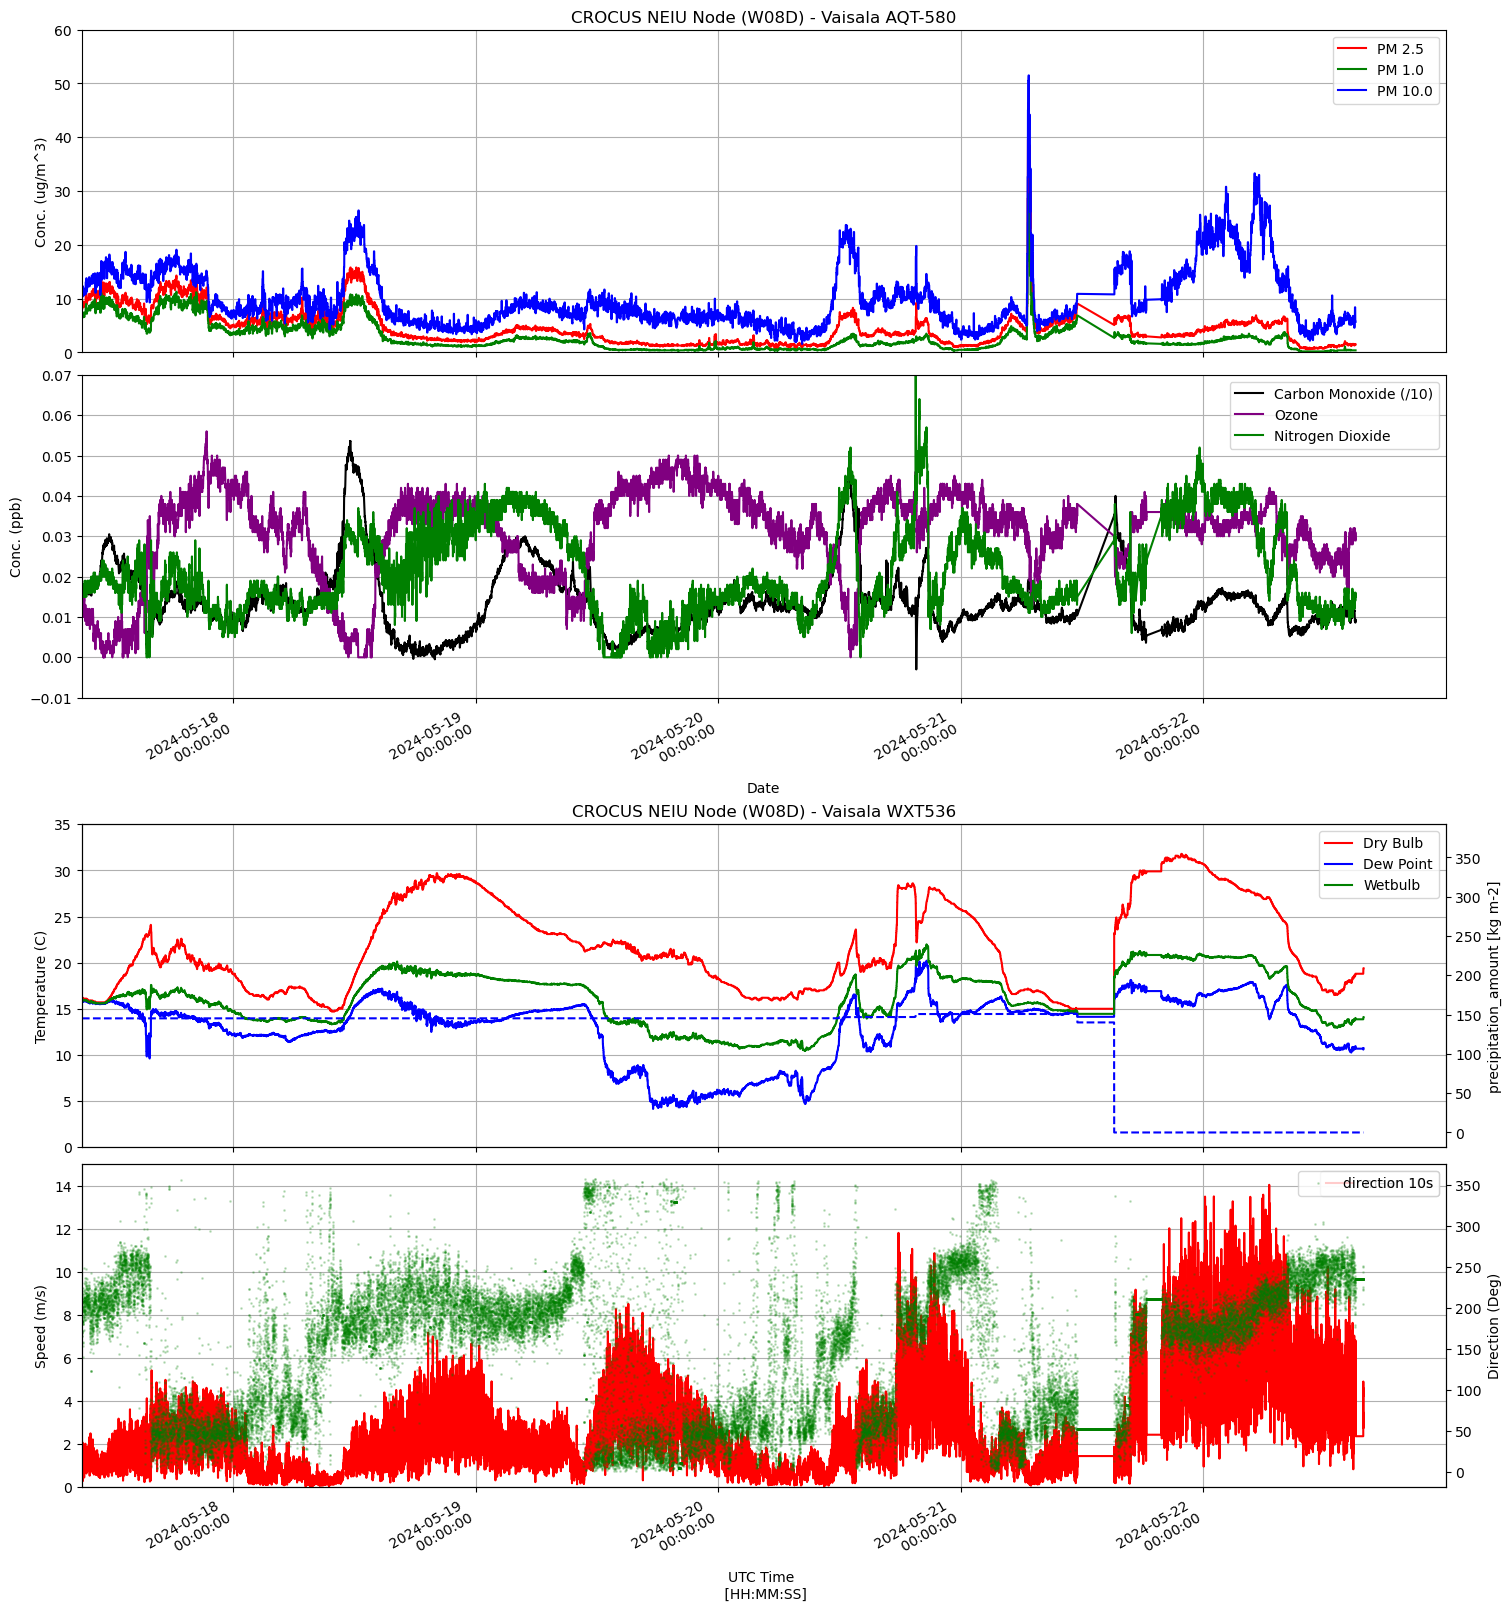

In [31]:
#time1 = pd.Timestamp("2023-08-01 00:00:00")
#time2 = pd.Timestamp("2023-09-10 23:00:00")


fig, axs = plt.subplots( ncols=1, nrows=4, figsize=[15,16], constrained_layout=True)
xr_aqt['pm2.5'].plot(ax=axs[0], color='r', label='PM 2.5')
xr_aqt['pm1.0'].plot(ax=axs[0], color='g', label='PM 1.0')
xr_aqt['pm10.0'].plot(ax=axs[0], color='b', label='PM 10.0')

(xr_aqt.co/10.).plot(ax=axs[1], color='k', label='Carbon Monoxide (/10)')
xr_aqt.o3.plot(ax=axs[1], color='purple', label='Ozone')
#xr_aqt.no.plot(ax=axs[1], color='r', label='Nitrogen Monoxide ')
xr_aqt.no2.plot(ax=axs[1], color='g', label='Nitrogen Dioxide')

axs[0].set_ylim([0, 60])

axs[0].set_title('CROCUS NEIU Node (W08D) - Vaisala AQT-580')
axs[0].set_xlabel('')
axs[0].set_ylabel('Conc. (ug/m^3)')

axs[0].legend()

axs[1].set_title('')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Conc. (ppb)')

axs[1].legend()

axs[0].set_xlim(time1, time2)
axs[1].set_xlim(time1, time2)
axs[1].set_ylim([-0.01,0.07])
axs[0].set_xticklabels([])
axs[0].grid()
axs[1].grid()
date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")
axs[1].xaxis.set_major_formatter(date_form)


xr_wxt.temperature.plot(ax=axs[2], color='r', label='Dry Bulb')
xr_wxt.dewpoint.plot(color='b', label='Dew Point',ax=axs[2])
xr_wxt.wetbulb.plot(color='g', label='Wetbulb',ax=axs[2])

xr_wxt.wind_mean_10s.plot(ax=axs[3], color='r', label='mean 10s')
ytwin2 = plt.twinx()

xr_wxt.wind_dir_10s.plot(ax=ytwin2, color='g', label='direction 10s', marker='.', linestyle='none', 
                         markersize=2, alpha = 0.2)

axs[2].set_title('CROCUS NEIU Node (W08D) - Vaisala WXT536')
axs[2].set_xlabel('')
axs[2].set_ylabel('Temperature (C)')


axs[3].set_xlabel('UTC Time \n [HH:MM:SS]')
axs[3].set_ylabel('Speed (m/s)')
axs[2].grid()
axs[3].grid()

my_twin2 = plt.twinx(ax = axs[2])
xr_wxt.rainfall.plot(ax=my_twin2, label = 'Rainfall (mm)', color='b', linestyle='dashed')

my_twin.set_ylabel('Rainfall (mm)')
my_twin.legend(loc=1)


axs[2].legend()
axs[2].grid(True)

axs[3].legend()
axs[3].grid(True)

ytwin2.set_ylabel('Direction (Deg)')
ytwin2.legend(loc=1)

date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")

axs[3].xaxis.set_major_formatter(date_form)
axs[2].set_xticklabels([])

axs[3].set_xlim(time1, time2)
axs[2].set_xlim(time1, time2)

#my_twin.set_ylim(30,85)
axs[2].set_ylim(0,35)
axs[3].set_ylim(0,15)
plt.savefig('/Users/scollis/report2.png')





In [ ]:
time1 = pd.Timestamp("2023-05-17 00:00:00")
time2 = pd.Timestamp("2023-06-23 00:00:00")


fig, axs = plt.subplots( ncols=1, nrows=1, figsize=[10,4], constrained_layout=True)
xr_aqt['pm2.5'].plot(ax=axs, color='r', label='PM 2.5')
xr_aqt['pm1.0'].plot(ax=axs, color='g', label='PM 1.0')
xr_aqt['pm10.0'].plot(ax=axs, color='b', label='PM 10.0')



axs.set_title('CROCUS NEIU Node (W08D) - Vaisala AQT-580')
axs.set_xlabel('Time')
axs.set_ylabel('Conc. (ug/m^3)')

axs.legend()

axs.set_xlim(time1, time2)
axs.set_xlim(time1, time2)
axs.grid()

date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")
axs.xaxis.set_major_formatter(date_form)


In [ ]:


time1 = pd.Timestamp("2023-06-05 00:00:00")
time2 = pd.Timestamp("2023-06-07 00:00:00")


fig, axs = plt.subplots( ncols=1, nrows=2, figsize=[10,8], constrained_layout=True)
xr_aqt['pm2.5'].plot(ax=axs[0], color='r', label='PM 2.5')
xr_aqt['pm1.0'].plot(ax=axs[0], color='g', label='PM 1.0')
xr_aqt['pm10.0'].plot(ax=axs[0], color='b', label='PM 10.0')

(xr_aqt.co/10.).plot(ax=axs[1], color='k', label='Carbon Monoxide (/10)')
xr_aqt.o3.plot(ax=axs[1], color='purple', label='Ozone')
xr_aqt.no.plot(ax=axs[1], color='r', label='Nitrogen Monoxide ')
xr_aqt.no2.plot(ax=axs[1], color='g', label='Nitrogen Dioxide')


axs[0].set_title('CROCUS NEIU Node (W08D) - Vaisala AQT-580')
axs[0].set_xlabel('')
axs[0].set_ylabel('Conc. (ug/m^3)')

axs[0].legend()

axs[1].set_title('')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Conc. (ppb)')

axs[1].legend()

axs[0].set_xlim(time1, time2)
axs[1].set_xlim(time1, time2)
axs[1].set_ylim([-0.01,0.126])
axs[0].set_xticklabels([])
axs[0].grid()
axs[1].grid()

date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")
axs[1].xaxis.set_major_formatter(date_form)


In [ ]:
cl61_data = xr.open_dataset('/Users/scollis/data/QC-wildfire-plume.nc')

In [ ]:
figme = plt.figure(figsize=[16,5])
cl61_data.backscatter.transpose().plot( cmap=pyart.graph.cm_colorblind.ChaseSpectral, vmin = -8)
date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")
plt.gca().xaxis.set_major_formatter(date_form)


In [ ]:
my_glob = glob.glob('/Users/scollis/data/wxt/CMS_wxt536_NEIU_a1_2023060*')
xr_wxt = xr.open_mfdataset(my_glob)

In [ ]:


time1 = pd.Timestamp("2023-06-05 00:00:00")
time2 = pd.Timestamp("2023-06-07 00:00:00")


fig, axs = plt.subplots( ncols=1, nrows=3, figsize=[10,12], constrained_layout=True)
xr_aqt['pm2.5'].plot(ax=axs[0], color='r', label='PM 2.5')
xr_aqt['pm1.0'].plot(ax=axs[0], color='g', label='PM 1.0')
xr_aqt['pm10.0'].plot(ax=axs[0], color='b', label='PM 10.0')

(xr_aqt.co/10.).plot(ax=axs[1], color='k', label='Carbon Monoxide (/10)')
xr_aqt.o3.plot(ax=axs[1], color='purple', label='Ozone')
xr_aqt.no.plot(ax=axs[1], color='r', label='Nitrogen Monoxide ')
xr_aqt.no2.plot(ax=axs[1], color='g', label='Nitrogen Dioxide')


axs[0].set_title('CROCUS NEIU Node (W08D) - Vaisala AQT-580')
axs[0].set_xlabel('')
axs[0].set_ylabel('Conc. (ug/m^3)')


axs[1].set_title('')
axs[1].set_xlabel('')
axs[1].set_ylabel('Conc. (ppb)')



axs[0].set_xlim(time1, time2)
axs[1].set_xlim(time1, time2)
axs[1].set_ylim([-0.01,0.126])
axs[0].set_xticklabels([])
axs[1].set_xticklabels([])
axs[0].grid()
axs[1].grid()

my_twin = plt.twinx(ax = axs[1])
xr_wxt.rainfall.plot(ax=my_twin, label = 'Rainfall (mm)', color='b', linestyle='dashed')

my_twin.set_ylabel('Rainfall (mm)')

axs[1].legend()
axs[0].legend()
my_twin.legend()

cl61_data.backscatter.transpose().plot( cmap=pyart.graph.cm_colorblind.ChaseSpectral, 
                                       vmin = -8, vmax = -4, ax=axs[2])
axs[2].set_ylim([0,8000])
axs[2].set_xlim(time1, time2)

date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")
axs[2].xaxis.set_major_formatter(date_form)




In [ ]:


time1 = pd.Timestamp("2023-06-05 00:00:00")
time2 = pd.Timestamp("2023-06-07 00:00:00")


fig, axs = plt.subplots( ncols=1, nrows=3, figsize=[10,12], constrained_layout=True)
xr_aqt['pm2.5'].plot(ax=axs[0], color='r', label='PM 2.5')
xr_aqt['pm1.0'].plot(ax=axs[0], color='g', label='PM 1.0')
xr_aqt['pm10.0'].plot(ax=axs[0], color='b', label='PM 10.0')

(xr_aqt.co/10.).plot(ax=axs[1], color='k', label='Carbon Monoxide (/10)')
xr_aqt.o3.plot(ax=axs[1], color='purple', label='Ozone')
xr_aqt.no.plot(ax=axs[1], color='r', label='Nitrogen Monoxide ')
xr_aqt.no2.plot(ax=axs[1], color='g', label='Nitrogen Dioxide')


axs[0].set_title('CROCUS NEIU Node (W08D) - Vaisala AQT-580')
axs[0].set_xlabel('')
axs[0].set_ylabel('Conc. (ug/m^3)')


axs[1].set_title('')
axs[1].set_xlabel('')
axs[1].set_ylabel('Conc. (ppb)')



axs[0].set_xlim(time1, time2)
axs[1].set_xlim(time1, time2)
axs[1].set_ylim([-0.01,0.126])
axs[0].set_xticklabels([])
axs[1].set_xticklabels([])
axs[0].grid()
axs[1].grid()

my_twin = plt.twinx(ax = axs[1])
xr_wxt.rainfall.plot(ax=my_twin, label = 'Rainfall (mm)', color='b', linestyle='dashed')

my_twin.set_ylabel('Rainfall (mm)')

axs[1].legend()
axs[0].legend()
my_twin.legend()

cl61_data.linear_depol_ratio.transpose().plot( cmap=pyart.graph.cm_colorblind.ChaseSpectral, 
                                       vmax=.6, vmin=-.2, ax=axs[2])
axs[2].set_ylim([0,8000])
axs[2].set_xlim(time1, time2)

date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")
axs[2].xaxis.set_major_formatter(date_form)




In [ ]:
plt.twinx?

In [ ]:
cl61_data

In [ ]:
my_glob = glob.glob('/Users/scollis/data/wxt/CMS_wxt536_NU_a1_20240509_000000Z.nc')
xr_wxt_NU = xr.open_mfdataset(my_glob)
my_glob = glob.glob('/Users/scollis/data/wxt/CMS_wxt536_NEIU_a1_20240509_000000Z.nc')
xr_wxt_NEIU = xr.open_mfdataset(my_glob)


In [ ]:
xr_wxt_NEIU

In [ ]:
time1 = None# pd.Timestamp("2023-08-01 05:00:00")
time2 = None# pd.Timestamp("2023-09-09 19:00:00")

xr_wxt = xr_wxt_NU

#baseline the rainfall

xr_wxt['rainfall'] =xr_wxt['rainfall'] - xr_wxt['rainfall'][0]

fig, axs = plt.subplots( ncols=1, nrows=2, figsize=[10,8], constrained_layout=True)
xr_wxt.temperature.plot(ax=axs[0], color='r', label='Dry Bulb')
xr_wxt.dewpoint.plot(color='b', label='Dew Point',ax=axs[0])
xr_wxt.wetbulb.plot(color='g', label='Wetbulb',ax=axs[0])

xr_wxt.wind_mean_10s.plot(ax=axs[1], color='r', label='mean 10s')
ytwin = plt.twinx()

xr_wxt.wind_dir_10s.plot(ax=ytwin, color='g', label='direction 10s', marker='.', linestyle='none', 
                         markersize=2, alpha = 0.2)

axs[0].set_title('CROCUS ' + xr_wxt.site_ID + ' Node (' + xr_wxt.WSN + ') - Vaisala WXT536')
axs[0].set_xlabel('')
axs[0].set_ylabel('Temperature (C)')


axs[1].set_xlabel('UTC Time \n [HH:MM:SS]')
axs[1].set_ylabel('Speed (m/s)')
axs[0].grid()
axs[1].grid()

my_twin = plt.twinx(ax = axs[0])
xr_wxt.rainfall.plot(ax=my_twin, label = 'Rainfall (mm)', color='b', linestyle='dashed')

my_twin.set_ylabel('Rainfall (mm)')
my_twin.legend(loc=1)


axs[0].legend()
axs[0].grid(True)

axs[1].legend()
axs[1].grid(True)

ytwin.set_ylabel('Direction (Deg)')
ytwin.legend(loc=1)

date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")

axs[1].xaxis.set_major_formatter(date_form)
axs[0].set_xticklabels([])

axs[1].set_xlim(time1, time2)
axs[0].set_xlim(time1, time2)

#my_twin.set_ylim(30,85)
axs[0].set_ylim(0,25)






In [ ]:
time1 = None# pd.Timestamp("2023-08-01 05:00:00")
time2 = None# pd.Timestamp("2023-09-09 19:00:00")

xr_wxt = xr_wxt_NEIU
xr_wxt['rainfall'] =xr_wxt['rainfall'] - xr_wxt['rainfall'][0]

fig, axs = plt.subplots( ncols=1, nrows=2, figsize=[10,8], constrained_layout=True)
xr_wxt.temperature.plot(ax=axs[0], color='r', label='Dry Bulb')
xr_wxt.dewpoint.plot(color='b', label='Dew Point',ax=axs[0])
xr_wxt.wetbulb.plot(color='g', label='Wetbulb',ax=axs[0])

xr_wxt.wind_mean_10s.plot(ax=axs[1], color='r', label='mean 10s')
ytwin = plt.twinx()

xr_wxt.wind_dir_10s.plot(ax=ytwin, color='g', label='direction 10s', marker='.', linestyle='none', 
                         markersize=2, alpha = 0.2)

axs[0].set_title('CROCUS ' + xr_wxt.site_ID + ' Node (' + xr_wxt.WSN + ') - Vaisala WXT536')
axs[0].set_xlabel('')
axs[0].set_ylabel('Temperature (C)')


axs[1].set_xlabel('UTC Time \n [HH:MM:SS]')
axs[1].set_ylabel('Speed (m/s)')
axs[0].grid()
axs[1].grid()

my_twin = plt.twinx(ax = axs[0])
xr_wxt.rainfall.plot(ax=my_twin, label = 'Rainfall (mm)', color='b', linestyle='dashed')

my_twin.set_ylabel('Rainfall (mm)')
my_twin.legend(loc=1)


axs[0].legend()
axs[0].grid(True)

axs[1].legend()
axs[1].grid(True)

ytwin.set_ylabel('Direction (Deg)')
ytwin.legend(loc=1)

date_form = DateFormatter("%Y-%m-%d \n %H:%M:%S")

axs[1].xaxis.set_major_formatter(date_form)
axs[0].set_xticklabels([])

axs[1].set_xlim(time1, time2)
axs[0].set_xlim(time1, time2)

#my_twin.set_ylim(30,85)
axs[0].set_ylim(0,25)






In [53]:
df = sage_data_client.query(
    start="2024-07-28T09:00:00Z",
    end="2024-07-28T10:00:00.000Z", 
    filter={
        "plugin": "10.31.81.1:5000/local/waggle-wxt536.*",
        "vsn": "W09E",
        "name": "wxt.env.temp"
    }
)

In [54]:
df

,timestamp,name,value,meta.host,meta.job,meta.missing,meta.node,meta.plugin,meta.sensor,meta.task,meta.units,meta.vsn,meta.zone
0,2024-07-28 09:00:00.223050442+00:00,wxt.env.temp,24.2,000048b02dd3c454.ws-nxcore,Pluginctl,-9999.9,000048b02dd3c454,10.31.81.1:5000/local/waggle-wxt536,vaisala-wxt536,wxt-536,degree Celsius,W09E,core
1,2024-07-28 09:00:01.184012431+00:00,wxt.env.temp,24.2,000048b02dd3c454.ws-nxcore,Pluginctl,-9999.9,000048b02dd3c454,10.31.81.1:5000/local/waggle-wxt536,vaisala-wxt536,wxt-536,degree Celsius,W09E,core
2,2024-07-28 09:00:02.191550435+00:00,wxt.env.temp,24.2,000048b02dd3c454.ws-nxcore,Pluginctl,-9999.9,000048b02dd3c454,10.31.81.1:5000/local/waggle-wxt536,vaisala-wxt536,wxt-536,degree Celsius,W09E,core
3,2024-07-28 09:00:03.184393288+00:00,wxt.env.temp,24.2,000048b02dd3c454.ws-nxcore,Pluginctl,-9999.9,000048b02dd3c454,10.31.81.1:5000/local/waggle-wxt536,vaisala-wxt536,wxt-536,degree Celsius,W09E,core
4,2024-07-28 09:00:04.958817822+00:00,wxt.env.temp,24.2,000048b02dd3c454.ws-nxcore,Pluginctl,-9999.9,000048b02dd3c454,10.31.81.1:5000/local/waggle-wxt536,vaisala-wxt536,wxt-536,degree Celsius,W09E,core
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3655,2024-07-28 09:59:55.142517426+00:00,wxt.env.temp,24.1,000048b02dd3c454.ws-nxcore,Pluginctl,-9999.9,000048b02dd3c454,10.31.81.1:5000/local/waggle-wxt536,vaisala-wxt536,wxt-536,degree Celsius,W09E,core
3656,2024-07-28 09:59:56.134781015+00:00,wxt.env.temp,24.1,000048b02dd3c454.ws-nxcore,Pluginctl,-9999.9,000048b02dd3c454,10.31.81.1:5000/local/waggle-wxt536,vaisala-wxt536,wxt-536,degree Celsius,W09E,core
3657,2024-07-28 09:59:57.142341001+00:00,wxt.env.temp,24.1,000048b02dd3c454.ws-nxcore,Pluginctl,-9999.9,000048b02dd3c454,10.31.81.1:5000/local/waggle-wxt536,vaisala-wxt536,wxt-536,degree Celsius,W09E,core
3658,2024-07-28 09:59:58.134660270+00:00,wxt.env.temp,24.1,000048b02dd3c454.ws-nxcore,Pluginctl,-9999.9,000048b02dd3c454,10.31.81.1:5000/local/waggle-wxt536,vaisala-wxt536,wxt-536,degree Celsius,W09E,core
